# Phase 5 & 6: Advanced Analytics and Machine Learning

In this notebook, we predict `co2_per_capita` using global demographic and economic indicators.
We will train and compare **Random Forest** and **XGBoost** regressor models using RMSE, MAE, and R² scores to determine the best model.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

print("Loading Processed Global Dataset...")
df = pd.read_csv('../data/processed/global_data.csv')


Loading Processed Global Dataset...


In [2]:
features = ['gdp_constant_usd', 'population', 'life_expectancy', 'primary_energy_consumption']
target = 'co2_per_capita'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 1. Random Forest Regressor

In [3]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_rmse = root_mean_squared_error(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print(f"Random Forest Performance:\nRMSE: {rf_rmse:.4f} | MAE: {rf_mae:.4f} | R²: {rf_r2:.4f}")

Random Forest Performance:
RMSE: 1.4610 | MAE: 0.4960 | R²: 0.9479


## 2. XGBoost Regressor

In [4]:
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

xgb_rmse = root_mean_squared_error(y_test, xgb_preds)
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_r2 = r2_score(y_test, xgb_preds)

print(f"XGBoost Performance:\nRMSE: {xgb_rmse:.4f} | MAE: {xgb_mae:.4f} | R²: {xgb_r2:.4f}")

XGBoost Performance:
RMSE: 1.4976 | MAE: 0.7157 | R²: 0.9452


## 3. Model Comparison & Best Model Selection

In [5]:
metrics = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'RMSE': [rf_rmse, xgb_rmse],
    'MAE': [rf_mae, xgb_mae],
    'R2 Score': [rf_r2, xgb_r2]
})
print("\nModel Comparison:")
display(metrics)

best_model_name = metrics.loc[metrics['RMSE'].idxmin()]['Model']
print(f"\nBest Model selected: {best_model_name} (Lowest RMSE)")


Model Comparison:


,Model,RMSE,MAE,R2 Score
0,Random Forest,1.460988,0.495952,0.947868
1,XGBoost,1.497623,0.715695,0.945221



Best Model selected: Random Forest (Lowest RMSE)


## 4. Feature Importance (Major Drivers of Emissions)

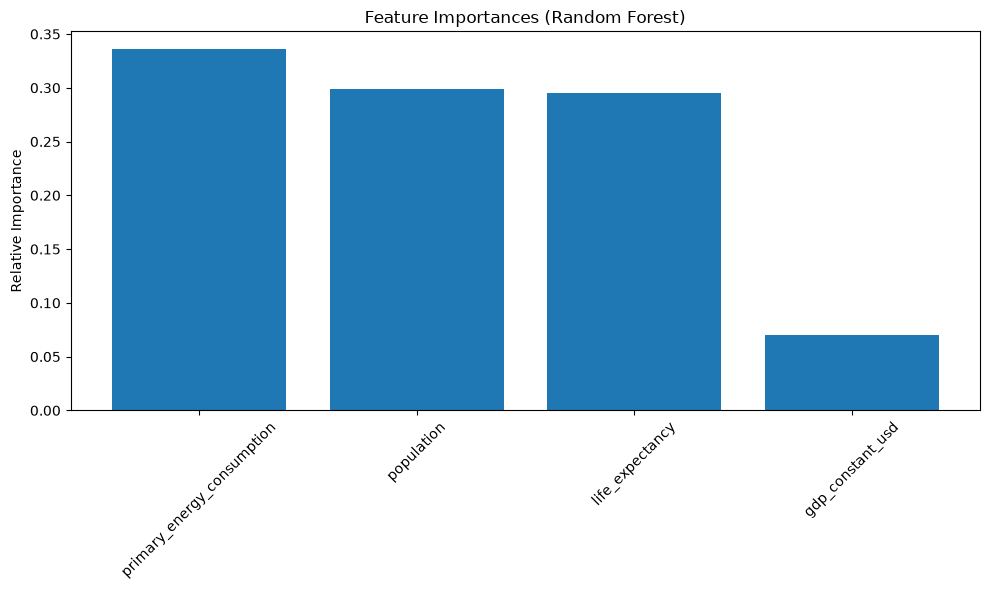

In [6]:
best_model = xgb_model if best_model_name == 'XGBoost' else rf
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title(f"Feature Importances ({best_model_name})")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.ylabel("Relative Importance")
plt.tight_layout()
plt.show()

## 5. Additional Models — Linear Regression & Gradient Boosting

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_rmse  = root_mean_squared_error(y_test, lr_preds)
lr_mae   = mean_absolute_error(y_test, lr_preds)
lr_mape  = mape(y_test.values, lr_preds)
lr_r2    = r2_score(y_test, lr_preds)
print(f'Linear Regression → RMSE: {lr_rmse:.4f} | MAE: {lr_mae:.4f} | MAPE: {lr_mape:.2f}% | R²: {lr_r2:.4f}')

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)
gb_rmse  = root_mean_squared_error(y_test, gb_preds)
gb_mae   = mean_absolute_error(y_test, gb_preds)
gb_mape  = mape(y_test.values, gb_preds)
gb_r2    = r2_score(y_test, gb_preds)
print(f'Gradient Boosting → RMSE: {gb_rmse:.4f} | MAE: {gb_mae:.4f} | MAPE: {gb_mape:.2f}% | R²: {gb_r2:.4f}')

# Also re-compute MAPE for RF and XGBoost
rf_mape  = mape(y_test.values, rf_preds)
xgb_mape = mape(y_test.values, xgb_preds)

# Extended comparison table
all_metrics = pd.DataFrame({
    'Model':    ['Linear Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting'],
    'RMSE':     [lr_rmse,   rf_rmse,   xgb_rmse,   gb_rmse],
    'MAE':      [lr_mae,    rf_mae,    xgb_mae,    gb_mae],
    'MAPE (%)': [lr_mape,   rf_mape,   xgb_mape,   gb_mape],
    'R² Score': [lr_r2,     rf_r2,     xgb_r2,     gb_r2],
})
print('\n--- Full Model Comparison ---')
display(all_metrics.set_index('Model').round(4))
best = all_metrics.loc[all_metrics['RMSE'].idxmin(), 'Model']
print(f'\n✅ Best Model: {best} (lowest RMSE)')

## 6. Principal Component Analysis (PCA)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features].dropna())

pca = PCA(n_components=4)
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(explained)+1), explained*100, color='#3498db', label='Individual')
ax.plot(range(1, len(explained)+1), cumulative*100, 'o-', color='#e74c3c', label='Cumulative')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.set_title('PCA — Explained Variance by Component', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'PC1 explains {explained[0]*100:.1f}% of variance')
print(f'PC1 + PC2 explain {cumulative[1]*100:.1f}% of variance')
print(f'PC1 + PC2 + PC3 explain {cumulative[2]*100:.1f}% of variance')

# Loadings
loadings = pd.DataFrame(pca.components_.T, index=features,
                         columns=[f'PC{i+1}' for i in range(4)])
print('\nPCA Loadings:')
display(loadings.round(3))

## 7. K-Means Cluster Analysis — Country Emission Profiles

In [ ]:
from sklearn.cluster import KMeans

# Use latest year per country for clustering
latest_year = df['year'].max()
cluster_df  = df[df['year'] == latest_year][['iso_code'] + features + ['co2']].dropna().set_index('iso_code')

scaler2  = StandardScaler()
X_cl     = scaler2.fit_transform(cluster_df[features + ['co2']])

# Elbow method
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cl)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_range), inertias, 'o-', color='#2980b9', linewidth=2)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (within-cluster SSE)')
ax.set_title('K-Means Elbow Method', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Fit with K=4
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df['Cluster'] = km4.fit_predict(X_cl)

print('\nCluster Size:')
print(cluster_df['Cluster'].value_counts())

print('\nCluster Centroids (mean CO₂ per cluster):')
display(cluster_df.groupby('Cluster')['co2'].mean().sort_values(ascending=False).rename('Avg CO₂ (Mt)').round(1))

## 8. OLS Regression — Causal Relationship Analysis

In [ ]:
import statsmodels.api as sm

ols_df = df[features + ['co2']].dropna()
X_ols  = sm.add_constant(ols_df[features])
y_ols  = ols_df['co2']

ols_model = sm.OLS(y_ols, X_ols).fit()
print(ols_model.summary())
print('\n--- Interpretation ---')
print('Coefficients with p < 0.05 are statistically significant drivers of CO₂ emissions.')